## What are Embeddings?

Think of embeddings as a way to translate words into language that computers understand - numbers!

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Simplified 2D example (real embeddings have hundreds of dimensions)
word_embeddings = {
    "cat": [0.8, 0.6],
    "kitten": [0.75, 0.65],
    "dog": [0.7, 0.3],
    "puppy": [0.65, 0.35],
    "car": [-0.5, 0.2],
    "truck": [-0.45, 0.15]
}

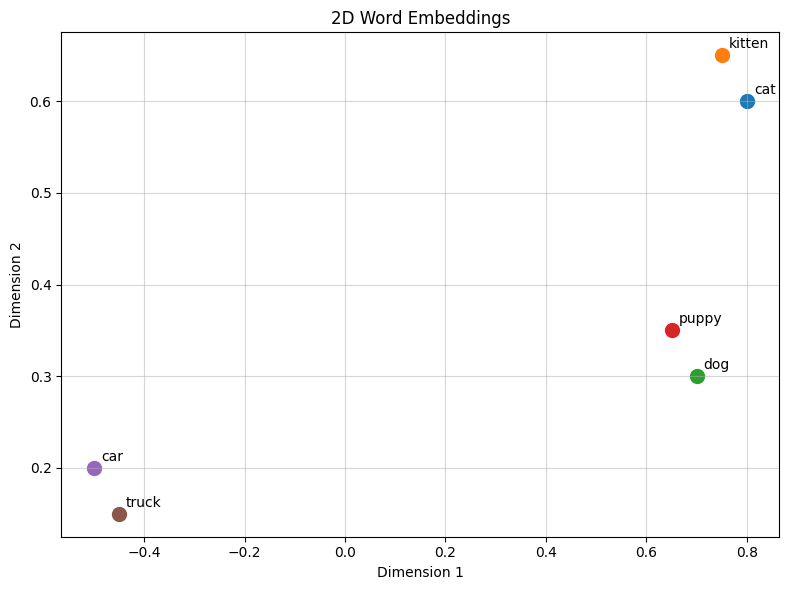

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))

for word, embedding in word_embeddings.items():
    ax.scatter(embedding[0], embedding[1], label=word, s=100)
    ax.annotate(word, (embedding[0], embedding[1]), xytext=(5, 5), textcoords='offset points')
ax.set_title("2D Word Embeddings")
ax.set_xlabel("Dimension 1")
ax.set_ylabel("Dimension 2")
ax.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

## Measuring the similarity

In [5]:
def cosine_similarity(vec1, vec2):
    """
    Cosine similarity measures the angle between two vectors.
    - Result close to 1: Very similar
    - Result close to 0: Not related
    - Result close to -1: Opposite meanings
    """
    dot_product = np.dot(vec1, vec2)
    norm_a = np.linalg.norm(vec1)
    norm_b = np.linalg.norm(vec2)
    return dot_product/(norm_a * norm_b)

In [7]:
# Example
cat_vector = [0.8, 0.6, 0.3]
kitten_vector = [0.75, 0.65, 0.35]
car_vector = [-0.5, 0.2, 0.1]

print(cosine_similarity(cat_vector,kitten_vector))

0.9966186334192183


In [8]:
cosine_similarity(cat_vector,car_vector)

np.float64(-0.4371858854891681)

### Creating Embeddings

In [9]:
### Huggingface and OpenAI models

from langchain_huggingface import HuggingFaceEmbeddings

## Initialize a simple Embedding model(no API key needed)
embedding = HuggingFaceEmbeddings(
    model_name = "sentence-transformers/all-MiniLM-L6-v2"
)


embedding

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, query_encode_kwargs={}, multi_process=False, show_progress=False)

In [10]:
## Create an embedding for a simple text
text = "The cat is on the roof."
text_embedding = embedding.embed_query(text)
print(f"Text: {text}")
print(f"Embedding length: {len(text_embedding)}")
print(f"Embedding: {text_embedding}")

Text: The cat is on the roof.
Embedding length: 384
Embedding: [0.0901421532034874, 0.07564273476600647, 0.02024746499955654, 0.012722780928015709, -0.04801316186785698, -0.01238959189504385, 0.014910437166690826, 0.020820681005716324, -0.0007705239695496857, 0.025479121133685112, -0.03893271088600159, 0.05134260654449463, 0.009062416851520538, -0.008285765536129475, -0.02177567221224308, 0.00042898047831840813, -0.0677620992064476, -0.012746315449476242, 0.0446496419608593, 0.04159591346979141, -0.0027068734634667635, -0.031539030373096466, 0.019125359132885933, -0.03482212498784065, -0.04329347237944603, 0.043301500380039215, -0.06230572238564491, -0.031219156458973885, -0.002523516770452261, -0.01685435138642788, -0.016138598322868347, -0.0036168433725833893, -0.07031164318323135, 0.06256607174873352, -0.014947694726288319, -0.057346411049366, -0.00033935558167286217, -0.041513606905937195, -0.01782078482210636, 0.0860838070511818, 0.03254357725381851, -0.0035632008221000433, -0.084

In [11]:
sentences = [
    "The cat is on the roof.",
    "A dog is in the yard.",
    "The car is parked outside.",
    "I love machine learning."
]

embedding_sentences = embedding.embed_documents(sentences)
for sentence, embedding in zip(sentences, embedding_sentences):
    print(f"Sentence: {sentence}")
    print(f"Embedding length: {len(embedding)}")
    print(f"Embedding: {embedding}\n")

Sentence: The cat is on the roof.
Embedding length: 384
Embedding: [0.0901421308517456, 0.07564278692007065, 0.02024744637310505, 0.012722828425467014, -0.04801314324140549, -0.012389554642140865, 0.014910397119820118, 0.02082066982984543, -0.0007705236785113811, 0.025479132309556007, -0.0389326736330986, 0.05134258419275284, 0.009062384255230427, -0.00828579906374216, -0.02177565172314644, 0.0004289940115995705, -0.06776208430528641, -0.012746275402605534, 0.04464961960911751, 0.04159592092037201, -0.00270692165941, -0.03153898939490318, 0.01912537030875683, -0.034822072833776474, -0.04329349845647812, 0.0433015376329422, -0.06230571120977402, -0.031219203025102615, -0.0025235353969037533, -0.01685432344675064, -0.016138585284352303, -0.0036168324295431376, -0.07031160593032837, 0.0625661090016365, -0.014947701245546341, -0.05734643340110779, -0.00033931591315194964, -0.04151357337832451, -0.017820702865719795, 0.0860838070511818, 0.0325435996055603, -0.0035632518120110035, -0.0842222

In [13]:
from langchain_huggingface import HuggingFaceEmbeddings
import time

# Popular models comparison
models = {
    "all-MiniLM-L6-v2": {
        "size": 384,
        "description": "Fast and efficient, good quality",
        "use_case": "General purpose, real-time applications"
    },
    "all-mpnet-base-v2": {
        "size": 768,
        "description": "Best quality, slower than MiniLM",
        "use_case": "When quality matters more than speed"
    },
    "all-MiniLM-L12-v2": {
        "size": 384,
        "description": "Slightly better than L6, bit slower",
        "use_case": "Good balance of speed and quality"
    },
    "multi-qa-MiniLM-L6-cos-v1": {
        "size": 384,
        "description": "Optimized for question-answering",
        "use_case": "Q&A systems, semantic search"
    },
    "paraphrase-multilingual-MiniLM-L12-v2": {
        "size": 384,
        "description": "Supports 50+ languages",
        "use_case": "Multilingual applications"
    }
}

print("Popular Open Source Embedding Models:\n")
for model_name, info in models.items():
    print(f"Model: sentence-transformers/{model_name}")
    print(f"   Embedding size: {info['size']} dimensions")
    print(f"   Description: {info['description']}")
    print(f"   Use case: {info['use_case']}\n")


Popular Open Source Embedding Models:

Model: sentence-transformers/all-MiniLM-L6-v2
   Embedding size: 384 dimensions
   Description: Fast and efficient, good quality
   Use case: General purpose, real-time applications

Model: sentence-transformers/all-mpnet-base-v2
   Embedding size: 768 dimensions
   Description: Best quality, slower than MiniLM
   Use case: When quality matters more than speed

Model: sentence-transformers/all-MiniLM-L12-v2
   Embedding size: 384 dimensions
   Description: Slightly better than L6, bit slower
   Use case: Good balance of speed and quality

Model: sentence-transformers/multi-qa-MiniLM-L6-cos-v1
   Embedding size: 384 dimensions
   Description: Optimized for question-answering
   Use case: Q&A systems, semantic search

Model: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
   Embedding size: 384 dimensions
   Description: Supports 50+ languages
   Use case: Multilingual applications

